# Dacon E-Commerce Dataset - Silver 등급 세부 분석

---

## 분석 개요

RFM 세그먼테이션에서 도출된 **Silver(재방문율 57.0%)** 를 대상으로 재구매 패턴과 이탈 구조를 심층 분석하고, Gold 전환 전략과 이탈 방어 방안을 제시한다.

| 항목 | 내용 |
|------|------|
| 분석 대상 | Silver |
| 분석 기간 | 2019-01-01 - 2019-12-31 |
| 고객 수 | 314명 (21.4%) |
| 매출 기여 | 전체 매출의 16.1% |

---

## 등급 프로파일

RFM 점수(20-100)는 R·F·M 점수(각 1-5)에 PCA 가중치(R 20.1% / F 33.9% / M 46.0%)를 적용해 산출한다.

| | Silver |
|---|---|
| RFM 점수 기준 | 50점 이상 - 65점 미만 |
| 재방문율 | 57.0% |
| 1인당 지출 | `$2,476` |

---

## 세그먼트 구성

| 세그먼트 | 비중 | 그룹 | 정의 |
|---------|:----:|:----:|------|
| 잠재 충성 고객 | **44.6%** | 안정군 | 최근 구매 이력 있음, 충성 고객으로 성장 가능성 높음 |
| 가망 고객 | 18.8% | 안정군 | 적절한 구매 빈도·금액, Recency 회복 시 Silver 유지 가능 |
| 휴면 고객 | 19.1% | 이탈군 | 과거 구매 이력 있으나 장기 미방문 상태 |
| 이탈 위험 고객 | 17.2% | 이탈군 | 과거 활동적이었으나 최근 방문 감소 중 |

안정군(63.4%) vs 이탈군(36.3%)

---

## 분석 배경

Silver는 전체 고객의 21.4%(314명)으로 전체 매출의 16.1%를 담당하는 성장 잠재층이다.  
재방문율 57.0%로 Gold(74.1%) 대비 17%p 낮고, 안정군(63.4%)과 이탈군(36.3%)이 공존하며,  
이탈 조짐 고객(Recency > 90일)이 전체의 59.6%(187명)에 달한다.

---

## 핵심 질문

**왜 안정군이 다수임에도 재방문율이 낮은가? Gold 전환은 가능한가? 이탈은 막을 수 있는가?**

| 가설 | 내용 |
|------|------|
| 가설 1 | Silver의 재방문율(57.0%)은 안정군(잠재충성·가망)과 이탈군(휴면·이탈위험)의 이분화 구조로 설명될 것이다 |
| 가설 2 | Silver 이탈 조짐 고객(Recency > 90일)의 마지막 구매도 특정 계절에 집중될 것이다 |
| 가설 3 | Silver 내 Gold 전환 갭이 가장 작은 세그먼트는 잠재 충성 고객일 것이다 |
| 가설 3-1 | Silver 내 이탈 조짐 고객은 RFM 점수 하한(50점쪽)에 더 많이 집중될 것이다 |
| 가설 4 | Silver의 이탈 세그먼트(휴면·이탈위험)는 안정 세그먼트(잠재충성·가망)보다 1인당 구매금액이 낮다 |

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

---
## 데이터 로드

`rfm_result` 테이블에 저장된 세그먼트를 로드하여 Silver 고객의 RFM 지표와 세그먼트를 한 번에 불러온다.

In [2]:
silver_rfm = pd.read_sql(
    """
    SELECT
        고객ID, 세그먼트, Recency, Frequency, Monetary, R, F, M, RFM_score
    FROM rfm_result
    WHERE 등급 = 'Silver'
    """,
    engine
)
silver_rfm.head()

,고객ID,세그먼트,Recency,Frequency,Monetary,R,F,M,RFM_score
0,USER_0003,가망 고객,17,11,1339.57,5,2,2,52.065053
1,USER_0004,휴면 고객,107,13,1369.94,3,3,2,50.800311
2,USER_0012,잠재 충성 고객,122,13,2217.09,3,3,3,60.000000
3,USER_0016,잠재 충성 고객,131,10,3182.75,3,2,3,53.221374
4,USER_0019,잠재 충성 고객,74,15,1744.39,4,3,2,54.821995


In [3]:
silver_rfm.shape

(314, 9)

In [4]:
silver_rfm.describe()

,Recency,Frequency,Monetary,R,F,M,RFM_score
count,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000
mean,131.436306,14.977707,2475.799045,3.171975,2.748408,2.812102,57.257573
std,93.499880,5.681325,933.751414,1.336049,0.533612,0.451883,4.430208
min,0.000000,2.000000,761.350000,1.000000,1.000000,2.000000,50.464431
25%,50.000000,11.000000,1846.762500,2.000000,2.000000,3.000000,52.065053
50%,118.000000,15.000000,2427.775000,3.000000,3.000000,3.000000,57.243058
75%,198.750000,18.000000,3129.927500,4.000000,3.000000,3.000000,60.000000
max,361.000000,43.000000,7164.800000,5.000000,4.000000,4.000000,64.021684


In [5]:
seg_color = {
    '잠재 충성 고객': '#2ecc71',
    '가망 고객': '#3498db',
    '휴면 고객': '#95a5a6',
    '이탈 위험 고객': '#e67e22',
    '놓치면 안될 고객': '#9b59b6',
}
seg_group_map = {
    '잠재 충성 고객': '안정군',
    '가망 고객': '안정군',
    '휴면 고객': '이탈군',
    '이탈 위험 고객': '이탈군',
    '놓치면 안될 고객': '이탈군',
}

seg_overview = (
    silver_rfm.groupby('세그먼트')
    .agg(
        고객수=('고객ID', 'count'),
        R_중앙값=('R', 'median'),
        F_중앙값=('F', 'median'),
        M_중앙값=('M', 'median'),
        RFM_score_중앙값=('RFM_score', 'median'),
        Recency_중앙값=('Recency', 'median'),
        Frequency_중앙값=('Frequency', 'median'),
        Monetary_중앙값=('Monetary', 'median'),
    )
    .round(2)
    .reset_index()
)
seg_overview['그룹'] = seg_overview['세그먼트'].map(seg_group_map)
seg_overview = seg_overview.sort_values('RFM_score_중앙값', ascending=False).reset_index(drop=True)
seg_overview

,세그먼트,고객수,R_중앙값,F_중앙값,M_중앙값,RFM_score_중앙값,Recency_중앙값,Frequency_중앙값,Monetary_중앙값,그룹
0,잠재 충성 고객,140,4.0,3.0,3.0,60.00,91.5,16.0,2469.70,안정군
1,휴면 고객,60,2.0,3.0,3.0,55.98,194.0,15.0,2427.67,이탈군
2,가망 고객,59,5.0,2.0,2.0,52.07,20.0,9.0,1340.11,안정군
3,이탈 위험 고객,54,1.0,3.0,3.0,51.96,278.0,19.0,3327.68,이탈군
4,놓치면 안될 고객,1,2.0,1.0,4.0,51.62,214.0,5.0,6670.01,이탈군


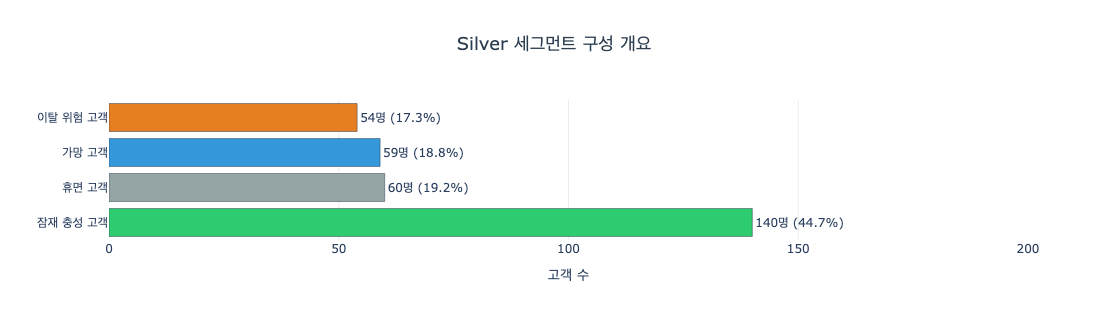

In [6]:
fig = go.Figure()

# 놓치면 안될 고객의 수가 1명 밖에 없기 때문에 시각화에서 제외
for _, row in seg_overview[seg_overview['세그먼트'] != '놓치면 안될 고객'].iterrows():
    seg = row['세그먼트']
    fig.add_trace(go.Bar(
        x=[row['고객수']],
        y=[seg],
        orientation='h',
        marker=dict(color=seg_color.get(seg, '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        text=[f"{row['고객수']}명 ({row['고객수']/313*100:.1f}%)"],  # 놓치면 안될 고객 1명 제외
        textposition='outside',
        showlegend=False,
    ))

fig.update_layout(
    title=dict(
        text='Silver 세그먼트 구성 개요<br>',
        x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')
    ),
    plot_bgcolor='white',
    xaxis=dict(title='고객 수', range=[0, 200], gridcolor='#ececec'),
    yaxis=dict(title=''),
    height=320,
)
fig.show()

> ⚠️ **분석 범위**: 놓치면 안될 고객(1명)은 표본이 너무 적어 이하 가설 검증 분석에서 제외한다. 

---
## 가설 1 — Silver의 재방문율은 안정군과 이탈군의 이분화 구조로 설명될 것이다

> **가설 1**: Silver의 낮은 재방문율(57.0%)은 이탈군 전체의 문제가 아닌, 안정군(잠재충성·가망)과 이탈군(휴면·이탈위험) 간의 이분화 구조에서 비롯될 것이다.
>
> - 근거: Gold 분석에서 세그먼트별 재방문율이 크게 달랐던 패턴(56.8%-87.0%)이 Silver에도 적용될 것
> - 검증: 세그먼트별 재방문율 및 Recency 분포 비교 → 안정군 vs 이탈군 비교

In [7]:
visit_h1 = pd.read_sql(
    """
    WITH visit_days AS (
        SELECT
            r.세그먼트,
            r.고객ID,
            COUNT(DISTINCT DATE(o.거래날짜)) AS 방문일수
        FROM rfm_result r
        JOIN orders_master o ON r.고객ID = o.고객ID
        WHERE r.등급 = 'Silver'
        GROUP BY r.세그먼트, r.고객ID
    )
    SELECT 세그먼트, 고객ID, 방문일수
    FROM visit_days
    """,
    engine
)
visit_h1 = visit_h1.merge(silver_rfm[['고객ID', 'Recency', 'R']], on='고객ID')
visit_h1['재방문'] = visit_h1['방문일수'] > 1
visit_h1['그룹'] = visit_h1['세그먼트'].map(seg_group_map)

seg_revisit = (
    visit_h1.groupby('세그먼트')
    .agg(
        재방문고객=('재방문', 'sum'),
        전체고객=('재방문', 'count')
    )
    .assign(재방문율=lambda x: (x['재방문고객'] / x['전체고객'] * 100).round(1))
    .reset_index()
    .sort_values('재방문율', ascending=False)
)

h1_stats = (
    visit_h1.groupby('세그먼트')[['Recency', 'R']]
    .agg(['mean', 'median'])
    .round(1)
    .reset_index()
)
h1_stats.columns = ['세그먼트', 'Recency_평균', 'Recency_중앙값', 'R_평균', 'R_중앙값']
h1_stats = (
    h1_stats
    .merge(seg_revisit[['세그먼트', '재방문율', '재방문고객', '전체고객']], on='세그먼트')
    .sort_values('재방문율', ascending=False)
    .reset_index(drop=True)
)
h1_stats

,세그먼트,Recency_평균,Recency_중앙값,R_평균,R_중앙값,재방문율,재방문고객,전체고객
0,놓치면 안될 고객,214.0,214.0,2.0,2.0,100.0,1,1
1,잠재 충성 고객,94.4,91.5,3.6,4.0,64.3,90,140
2,휴면 고객,187.0,194.0,2.2,2.0,56.7,34,60
3,가망 고객,22.6,20.0,5.0,5.0,49.2,29,59
4,이탈 위험 고객,283.2,278.0,1.1,1.0,46.3,25,54


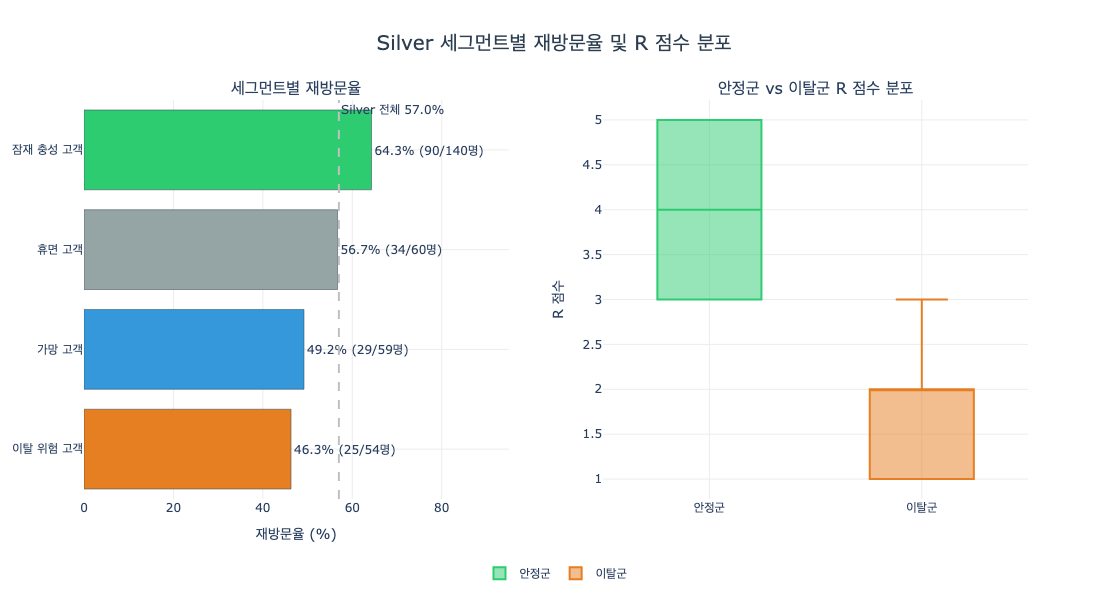

In [8]:
h1_plot = seg_revisit[seg_revisit['세그먼트'] != '놓치면 안될 고객'].copy()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['세그먼트별 재방문율', '안정군 vs 이탈군 R 점수 분포']
)

for _, row in h1_plot.sort_values('재방문율').iterrows():
    fig.add_trace(go.Bar(
        x=[row['재방문율']],
        y=[row['세그먼트']],
        orientation='h',
        marker=dict(color=seg_color.get(row['세그먼트'], '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        text=[f"{row['재방문율']:.1f}% ({int(row['재방문고객'])}/{int(row['전체고객'])}명)"],
        textposition='outside',
        showlegend=False,
    ), row=1, col=1)

for group, color in [('안정군', '#2ecc71'), ('이탈군', '#e67e22')]:
    sub = visit_h1[visit_h1['그룹'] == group]['R']
    fig.add_trace(go.Box(
        y=sub,
        name=group,
        marker_color=color,
        boxpoints='outliers',
    ), row=1, col=2)

fig.add_vline(
    x=57.0, line_dash='dash', line_color='#C0C0C0', line_width=2,
    annotation_text='Silver 전체 57.0%', annotation_position='top right',
    row=1, col=1
)

fig.update_layout(
    title=dict(
        text='Silver 세그먼트별 재방문율 및 R 점수 분포',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    height=600,
    legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5)
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_xaxes(title_text='재방문율 (%)', range=[0, 95], row=1, col=1)
fig.update_yaxes(title_text='R 점수', row=1, col=2)
fig.show()

> ### 📊 가설 1 검증 결과: 기각
>
> | 세그먼트 | 재방문율 | R 중앙값 | Recency 중앙값 | Recency 평균 | 그룹 |
> | :--- | :---: | :---: | :---: | :---: | :--- |
> | 잠재 충성 고객 | **64.3%** | 4.0 | 91.5일 | 94.4일 | 안정군 |
> | 휴면 고객 | 56.7% | 2.0 | 194.0일 | 187.0일 | 이탈군 |
> | 가망 고객 | 49.2% | 5.0 | 20.0일 | 22.6일 | 안정군 |
> | 이탈 위험 고객 | **46.3%** | 1.0 | 278.0일 | 283.2일 | 이탈군 |
>
> **💡 핵심 요약**
> Silver 등급의 재방문율(57.0%)은 안정군·이탈군 이분화로 단순 설명되지 않는다.
>
> - 🚨 **이탈 위험 고객 (46.3% | R=1.0)**: Recency 중앙값 278일로 Silver 내 최장 침묵. Silver 전체 재방문율을 가장 강하게 끌어내린다.
> - ⚠️ **휴면 고객 (56.7% | R=2.0)**: 이탈군임에도 가망(49.2%)보다 재방문율이 높다 — 과거 구매 이력이 일정 수준 재방문을 유지시키고 있다.
> - 📈 **가망 고객 (49.2% | R=5.0)**: Recency 중앙값 20.0일로 최근 구매가 가장 활발하지만, F·M이 낮아 재방문율은 안정군 중 오히려 낮다.
> - 🌱 **잠재 충성 고객 (64.3% | R=4.0)**: Silver 전체 재방문율을 끌어올리는 핵심. Recency 중앙값 91.5일로 이탈 조짐 경계(90일)에 위치해 주의가 필요하다.

---
## 가설 2 — Silver 이탈 조짐 고객의 마지막 구매도 특정 계절에 집중될 것이다

> **가설 2**: Gold 분석에서 이탈 조짐 고객(Recency > 90일)의 마지막 구매가 7-8월에 집중된 패턴이 Silver에도 동일하게 나타날 것이다.
>
> - 기준: Gold 분석과 동일하게 Recency > 90일 = 이탈 조짐 고객
> - 근거: 계절성 이탈이 등급을 가리지 않는다면 Silver에서도 같은 패턴이 관찰될 것
> - 검증: Silver 이탈 조짐 고객의 월별 마지막 구매 분포 + 체류 기간(첫구매-마지막구매) 분포

In [9]:
timing_data = pd.read_sql(
    """
    SELECT
        r.고객ID,
        r.세그먼트,
        DATE(MIN(o.거래날짜)) AS 첫구매일,
        DATE(MAX(o.거래날짜)) AS 마지막구매일,
        DATEDIFF('2019-12-31', MAX(DATE(o.거래날짜))) AS Recency
    FROM rfm_result r
    JOIN orders_master o ON r.고객ID = o.고객ID
    WHERE r.등급 = 'Silver'
    GROUP BY r.고객ID, r.세그먼트
    """,
    engine
)
timing_data['이탈조짐'] = timing_data['Recency'] > 90
timing_data['마지막구매월'] = pd.to_datetime(timing_data['마지막구매일']).dt.month
timing_data['체류기간'] = (
    pd.to_datetime(timing_data['마지막구매일']) - pd.to_datetime(timing_data['첫구매일'])
).dt.days

max_gap = pd.read_sql(
    """
    WITH 구매일목록 AS (
        SELECT o.고객ID, DATE(o.거래날짜) AS 구매일
        FROM orders_master o
        JOIN rfm_result r ON o.고객ID = r.고객ID
        WHERE r.등급 = 'Silver'
        GROUP BY o.고객ID, DATE(o.거래날짜)
    ),
    간격계산 AS (
        SELECT 고객ID, 구매일,
            LAG(구매일) OVER (PARTITION BY 고객ID ORDER BY 구매일) AS 이전구매일
        FROM 구매일목록
    )
    SELECT 고객ID, MAX(DATEDIFF(구매일, 이전구매일)) AS 최대구매간격
    FROM 간격계산
    WHERE 이전구매일 IS NOT NULL
    GROUP BY 고객ID
    """,
    engine
)
timing_data = timing_data.merge(max_gap, on='고객ID', how='left')
timing_data['최대구매간격'] = timing_data['최대구매간격'].fillna(0).astype(int)
timing_data['복귀고객'] = (timing_data['최대구매간격'] > 90) & (~timing_data['이탈조짐'])

total = len(timing_data)
total_churn = int(timing_data['이탈조짐'].sum())
total_복귀 = int(timing_data['복귀고객'].sum())
total_정상 = total - total_churn - total_복귀

print(f"정상: {total_정상}명 ({total_정상/total*100:.1f}%)")
print(f"이탈 후 복귀: {total_복귀}명 ({total_복귀/total*100:.1f}%)")
print(f"이탈 조짐: {total_churn}명 ({total_churn/total*100:.1f}%)")

churn_monthly = (
    timing_data[timing_data['이탈조짐']]
    .groupby('마지막구매월')
    .size()
    .reset_index(name='이탈고객수')
)
churn_monthly

정상: 85명 (27.1%)
이탈 후 복귀: 42명 (13.4%)
이탈 조짐: 187명 (59.6%)


,마지막구매월,이탈고객수
0,1,10
1,2,8
2,3,13
3,4,17
4,5,19
5,6,24
6,7,14
7,8,48
8,9,32
9,10,2


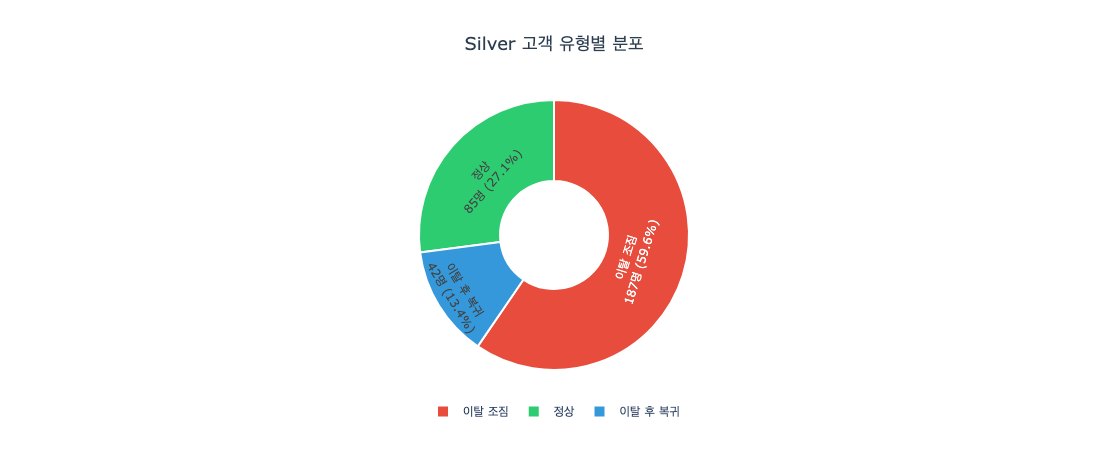

In [10]:
labels = ['정상', '이탈 후 복귀', '이탈 조짐']
values = [total_정상, total_복귀, total_churn]
colors = ['#2ecc71', '#3498db', '#e74c3c']

fig = go.Figure(go.Pie(
    labels=labels,
    values=values,
    marker=dict(colors=colors, line=dict(color='white', width=2)),
    textinfo='label+percent+value',
    texttemplate='%{label}<br>%{value}명 (%{percent})',
    hole=0.4
))

fig.update_layout(
    title=dict(
        text='Silver 고객 유형별 분포',
        font=dict(size=18, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    legend=dict(orientation='h', yanchor='top', y=-0.1, xanchor='center', x=0.5),
    height=450
)
fig.show()

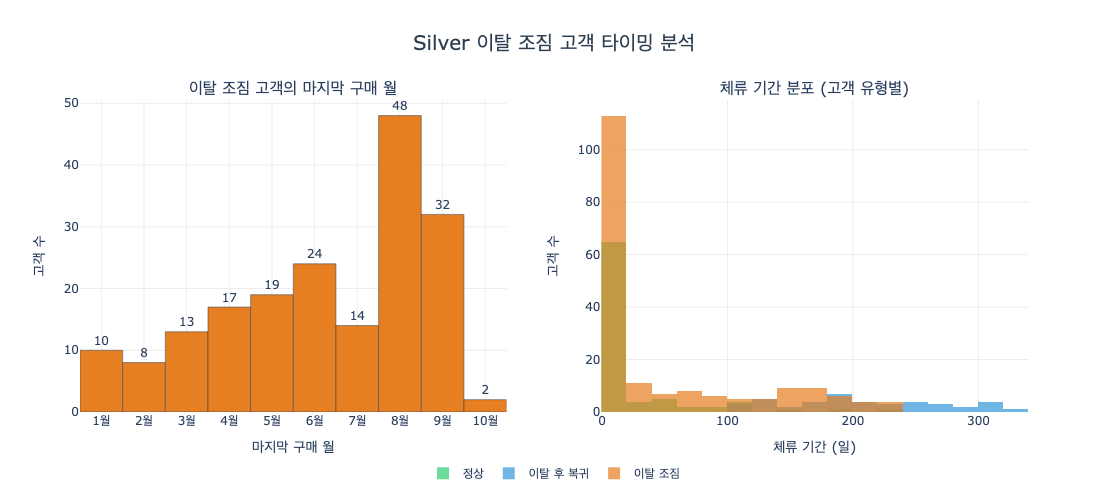

In [11]:
month_labels = {
    1: '1월', 2: '2월', 3: '3월', 4: '4월', 5: '5월', 6: '6월',
    7: '7월', 8: '8월', 9: '9월', 10: '10월', 11: '11월', 12: '12월'
}
churn_monthly['월'] = churn_monthly['마지막구매월'].map(month_labels)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['이탈 조짐 고객의 마지막 구매 월', '체류 기간 분포 (고객 유형별)']
)

fig.add_trace(go.Bar(
    x=churn_monthly['월'],
    y=churn_monthly['이탈고객수'],
    marker=dict(color='#e67e22', line=dict(color='#2c3e50', width=0.5)),
    text=churn_monthly['이탈고객수'],
    textposition='outside',
    showlegend=False,
), row=1, col=1)

hist_groups = [
    (timing_data[~timing_data['이탈조짐'] & ~timing_data['복귀고객']]['체류기간'], '#2ecc71', '정상'),
    (timing_data[timing_data['복귀고객']]['체류기간'], '#3498db', '이탈 후 복귀'),
    (timing_data[timing_data['이탈조짐']]['체류기간'], '#e67e22', '이탈 조짐'),
]
for sub, color, name in hist_groups:
    fig.add_trace(go.Histogram(
        x=sub,
        name=name,
        marker_color=color,
        opacity=0.7,
        nbinsx=15,
    ), row=1, col=2)

fig.update_layout(
    title=dict(
        text='Silver 이탈 조짐 고객 타이밍 분석',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    height=500,
    barmode='overlay',
    legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5)
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_xaxes(title_text='마지막 구매 월', row=1, col=1)
fig.update_xaxes(title_text='체류 기간 (일)', row=1, col=2)
fig.update_yaxes(title_text='고객 수', row=1, col=1)
fig.update_yaxes(title_text='고객 수', row=1, col=2)
fig.show()

> ### 📊 가설 2 검증 결과: 부분 채택
>
> | 구분 | 고객 수 | 비중 |
> | :--- | :---: | :---: |
> | 정상 (Recency ≤ 90일, 최대 간격 ≤ 90일) | 85명 | 27.1% |
> | 이탈 후 복귀 (최대 간격 > 90일, 현재 정상) | 42명 | 13.4% |
> | 이탈 조짐 (Recency > 90일) | 187명 | 59.6% |
> | **전체** | **314명** | **100%** |
>
> **1. 이탈 조짐 현황**
> - Silver 고객 **59.6%(187명)** 이 이탈 조짐 상태 — Gold(53.5%)보다 높아 리텐션 개입이 더욱 시급하다.
> - **연중 90일 이상 구매 공백 경험**: 73.0%(229명) — 이탈 조짐(187명) + 이탈 후 복귀(42명)
> - 이탈 후 복귀 42명: 잠재 충성(27명) + 가망(15명) — 한 번 공백을 극복하고 현재 정상 방문 중인 안정군
> - 세그먼트별 이탈 조짐: 이탈 위험(100%) · 휴면(100%) · 잠재 충성(51.4%) · 가망(0%)
>
> **2. 월별 이탈 시점 패턴**
> - 전체 이탈 조짐 고객의 마지막 구매는 **8월이 최다(48명, 25.7%)** 로, Gold의 여름 집중 패턴이 Silver에서도 부분 재현된다.
> - 단, 세그먼트별 이탈 시점은 뚜렷하게 갈린다 — Gold처럼 단일 집중이 아닌 분산 패턴이다.
> - **이탈 위험**: 1-4월 집중 (3월·4월 최다) — 상반기에 마지막 구매 후 이탈
> - **휴면**: 5-8월 집중 (6월 최다) — 여름에 마지막 구매 후 장기 이탈
> - 이탈 시점이 세그먼트별로 달라 재활성화 캠페인 타이밍을 세그먼트별로 분리해야 한다.
>
> **⚠️ 데이터 해석의 한계**
> - 단년도(1개년) 데이터의 특성상, 확인된 패턴이 매년 반복되는 실제 계절성(Seasonality)인지는 다년도 데이터로 재검증이 필요하다.

---
## 가설 3 — Silver 내 Gold 전환 갭이 가장 작은 세그먼트는 잠재 충성 고객일 것이다

> **가설 3**: 잠재 충성 고객은 R=4-5(최근성 높음)로 Gold 전환에 유리할 것이다. 단, F·M이 낮아 갭이 예상보다 클 수 있다.
>
> - 근거: Gold 분석의 가설 3에서 충성 고객(갭 4.02점)이 Platinum 전환 최근접이었듯, Silver에서도 R이 높은 세그먼트가 Gold 문턱에 가장 가까울 것
> - PCA 가중치 참고 (M 46.0% > F 33.9% > R 20.1%) — M·F가 점수를 결정적으로 좌우한다
> - 검증: 세그먼트별 RFM 포지션 확인 → Gold 갭(65 − RFM_score 중앙값) 비교 + Recency vs Monetary 분포

In [12]:
seg_summary = (
    silver_rfm.groupby('세그먼트')[['Recency', 'Frequency', 'Monetary', 'R', 'F', 'M', 'RFM_score']]
    .agg(['median', 'mean'])
    .round(1)
    .reset_index()
)
seg_summary.columns = [
    '세그먼트',
    'Recency_중앙값', 'Recency_평균',
    'Frequency_중앙값', 'Frequency_평균',
    'Monetary_중앙값', 'Monetary_평균',
    'R_중앙값', 'R_평균',
    'F_중앙값', 'F_평균',
    'M_중앙값', 'M_평균',
    'RFM_중앙값', 'RFM_평균',
]
seg_summary['Gold_갭'] = (65 - seg_summary['RFM_중앙값']).round(1)
seg_summary = seg_summary[seg_summary['세그먼트'] != '놓치면 안될 고객'].sort_values('Gold_갭').reset_index(drop=True)
seg_summary[['세그먼트', 'R_중앙값', 'F_중앙값', 'M_중앙값', 'RFM_중앙값', 'Gold_갭', 'Recency_중앙값', 'Monetary_중앙값']]

,세그먼트,R_중앙값,F_중앙값,M_중앙값,RFM_중앙값,Gold_갭,Recency_중앙값,Monetary_중앙값
0,잠재 충성 고객,4.0,3.0,3.0,60.0,5.0,91.5,2469.7
1,휴면 고객,2.0,3.0,3.0,56.0,9.0,194.0,2427.7
2,가망 고객,5.0,2.0,2.0,52.1,12.9,20.0,1340.1
3,이탈 위험 고객,1.0,3.0,3.0,52.0,13.0,278.0,3327.7


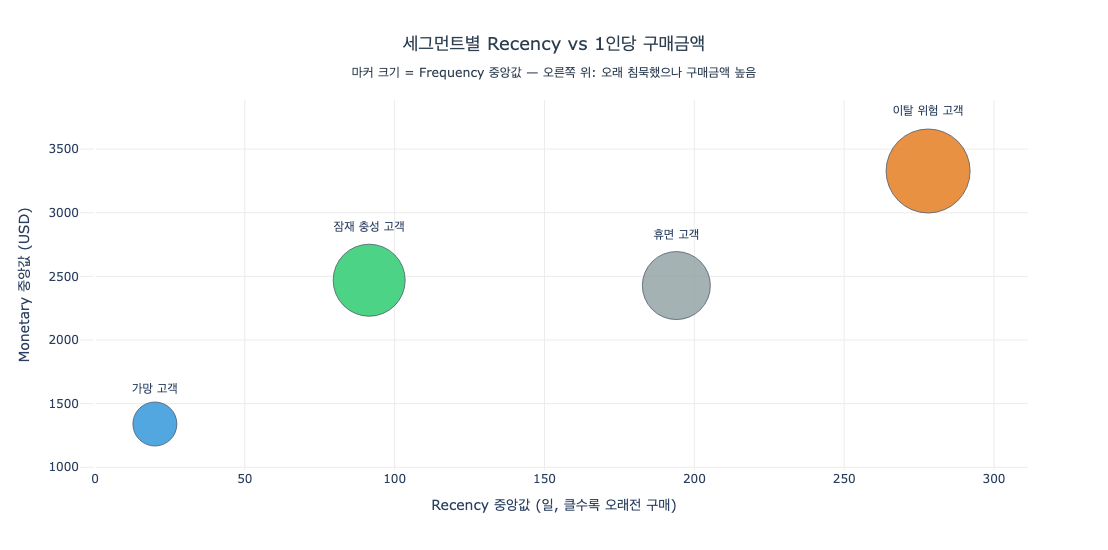

In [13]:
fig = go.Figure()
for _, row in seg_summary.iterrows():
    seg = row['세그먼트']
    fig.add_trace(go.Scatter(
        x=[row['Recency_중앙값']],
        y=[row['Monetary_중앙값']],
        mode='markers+text',
        marker=dict(
            size=row['Frequency_중앙값'] * 4 + 8,
            color=seg_color.get(seg, '#cccccc'),
            line=dict(color='#2c3e50', width=0.8),
            opacity=0.85
        ),
        text=[seg],
        textposition='top center',
        name=seg,
        showlegend=False,
    ))

fig.update_layout(
    title=dict(
        text='세그먼트별 Recency vs 1인당 구매금액<br><sub>마커 크기 = Frequency 중앙값 — 오른쪽 위: 오래 침묵했으나 구매금액 높음</sub>',
        font=dict(size=18, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(title='Recency 중앙값 (일, 클수록 오래전 구매)', gridcolor='#ececec'),
    yaxis=dict(title='Monetary 중앙값 (USD)', gridcolor='#ececec'),
    plot_bgcolor='white',
    width=700,
    height=550,
)
fig.show()

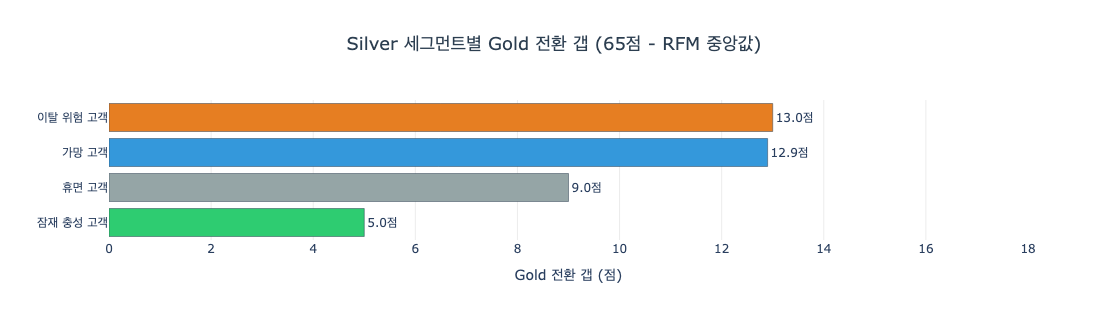

In [14]:
fig = go.Figure()
for _, row in seg_summary.iterrows():
    fig.add_trace(go.Bar(
        x=[row['Gold_갭']],
        y=[row['세그먼트']],
        orientation='h',
        marker=dict(color=seg_color.get(row['세그먼트'], '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        text=[f"{row['Gold_갭']}점"],
        textposition='outside',
        showlegend=False,
    ))

fig.update_layout(
    title=dict(
        text='Silver 세그먼트별 Gold 전환 갭 (65점 - RFM 중앙값)<br>',
        x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')
    ),
    plot_bgcolor='white',
    xaxis=dict(title='Gold 전환 갭 (점)', range=[0, 18], gridcolor='#ececec'),
    yaxis=dict(title=''),
    height=320,
)
fig.show()

> ### 📊 가설 3 검증 결과: 채택
>
> | 세그먼트 | R 중앙값 | F 중앙값 | M 중앙값 | RFM 중앙값 | Gold 갭 | Recency 중앙값 | Monetary 중앙값 |
> |---------|:------:|:------:|:------:|:---------:|:------:|:-----------:|:-----------:|
> | 잠재 충성 고객 | 4.0 | 3.0 | 3.0 | 60.0 | **5.0점** | 91.5일 | `$2,470` |
> | 휴면 고객 | 2.0 | 3.0 | 3.0 | 56.0 | 9.0점 | 194.0일 | `$2,428` |
> | 가망 고객 | 5.0 | 2.0 | 2.0 | 52.1 | 12.9점 | 20.0일 | `$1,340` |
> | 이탈 위험 고객 | 1.0 | 3.0 | 3.0 | 52.0 | 13.0점 | 278.0일 | `$3,328` |
>
> **💡 핵심 요약**
>
> - ✅ **잠재 충성(5.0점)** 이 Gold에 가장 가깝다 — R=4로 최근성이 높고, F·M=3이 공통 기준선을 충족한다.
> - 📌 **휴면(9.0점)** 이 가망(12.9점)·이탈위험(13.0점)보다 갭이 작다 — 과거 누적된 F·M이 점수를 받쳐준 결과다.
> - ⚠️ **가망과 이탈위험은 갭이 약 13점으로 유사** — Gold 전환보다 Silver 유지 자체가 더 시급한 과제다.
> - 🔍 **Recency vs Monetary 구조**: 이탈 위험(`$3,328`)은 오래 침묵했지만 고가치이고, 가망(`$1,340`)은 최근 구매했지만 저가치다. Recency와 Monetary가 반비례하는 구조로, 단일 캠페인으로 전체를 커버하기 어렵다.
>
> > ✅ **액션 아이템**: 잠재 충성(140명, 갭 5.0점)은 F·M 1회 부스트로 Gold 전환 가능 — 빈도·금액 부스터 캠페인 우선 타깃

---
## 가설 3-1 — Silver 내 이탈 조짐 고객은 RFM 점수 하한(50점쪽)에 더 많이 집중될 것이다

> **가설 3-1**: Silver 내에서 "하위 Silver" 고객(50점쪽, 하한 근처)이 "곧 Gold" 고객(65점쪽, 상한 근처)보다 이탈 조짐(Recency > 90일) 비율이 높을 것이다.
>
> - 배경: 가설 2에서 이탈 조짐 고객(187명, 59.6%)이 확인됨 — 이 이탈을 주도하는 RFM 구간이 어디인지 규명
> - 근거: RFM 점수가 고객 건강도를 반영하므로, 하위 Silver(50점쪽)는 상위 Silver(65점쪽)보다 이탈 위험 세그먼트 비중이 높을 것
> - 검증: 50-65점 구간을 3구간(50-55 / 55-60 / 60-65)으로 분할 → 구간별 이탈 조짐률 비교

In [15]:
h41_data = silver_rfm.merge(timing_data[['고객ID', '이탈조짐']], on='고객ID')
h41_data['점수구간'] = pd.cut(
    h41_data['RFM_score'],
    bins=[50, 55, 60, 65],
    labels=['50-55', '55-60', '60-65'],
    include_lowest=True
)

h41_bin = (
    h41_data.groupby('점수구간', observed=True)
    .agg(
        고객수=('고객ID', 'count'),
        이탈조짐수=('이탈조짐', 'sum')
    )
    .assign(이탈조짐률=lambda x: (x['이탈조짐수'] / x['고객수'] * 100).round(1))
    .reset_index()
)
h41_bin

h41_seg = (
    h41_data.groupby(['점수구간', '세그먼트'], observed=True)
    .agg(
        고객수=('고객ID', 'count'),
        이탈조짐수=('이탈조짐', 'sum')
    )
    .assign(이탈조짐률=lambda x: (x['이탈조짐수'] / x['고객수'] * 100).round(1))
    .reset_index()
)
(
    h41_seg
    .sort_values(['점수구간', '고객수'], ascending=[True, False])
    .reset_index(drop=True)
)

,점수구간,세그먼트,고객수,이탈조짐수,이탈조짐률
0,50-55,가망 고객,41,0,0.0
1,50-55,이탈 위험 고객,34,34,100.0
2,50-55,잠재 충성 고객,16,11,68.8
3,50-55,휴면 고객,15,15,100.0
4,50-55,놓치면 안될 고객,1,1,100.0
5,55-60,잠재 충성 고객,79,56,70.9
6,55-60,휴면 고객,45,45,100.0
7,55-60,이탈 위험 고객,5,5,100.0
8,60-65,잠재 충성 고객,45,5,11.1
9,60-65,가망 고객,18,0,0.0


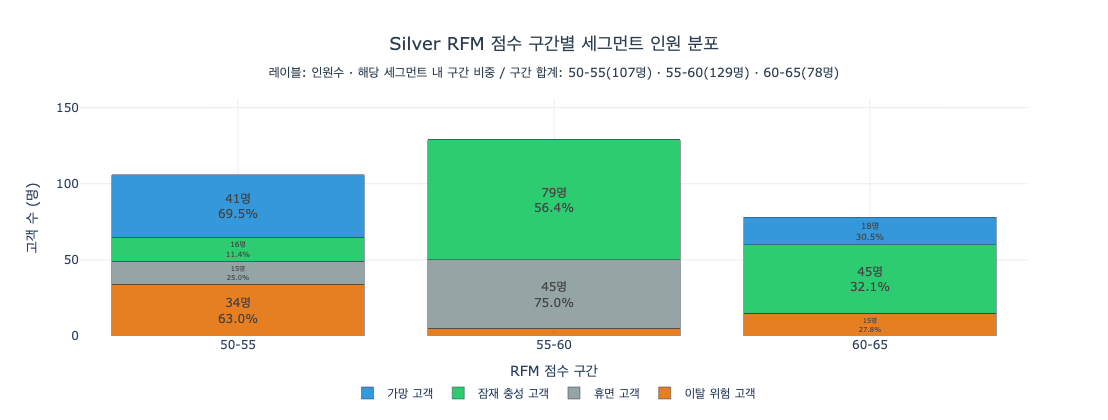

In [16]:
seg_totals_31 = h41_seg.groupby('세그먼트')['고객수'].sum()

fig = go.Figure()

seg_order_31 = ['이탈 위험 고객', '휴면 고객', '잠재 충성 고객', '가망 고객']
bands_31 = ['50-55', '55-60', '60-65']

for seg in seg_order_31:
    sub = h41_seg[h41_seg['세그먼트'] == seg].copy()
    sub['점수구간'] = sub['점수구간'].astype(str)
    counts = sub.set_index('점수구간')['고객수'].reindex(bands_31, fill_value=0)
    seg_total = seg_totals_31.get(seg, 1)
    text = [
        f"{int(v)}명<br>{v / seg_total * 100:.1f}%" if v >= 5 else (f"{int(v)}명" if v > 0 else '')
        for v in counts.values
    ]
    fig.add_trace(go.Bar(
        x=bands_31,
        y=counts.values,
        name=seg,
        marker=dict(color=seg_color.get(seg, '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        text=text,
        textposition='inside',
        insidetextanchor='middle',
    ))

fig.update_layout(
    title=dict(
        text='Silver RFM 점수 구간별 세그먼트 인원 분포<br><sub>레이블: 인원수 · 해당 세그먼트 내 구간 비중 / 구간 합계: 50-55(107명) · 55-60(129명) · 60-65(78명)</sub>',
        font=dict(size=18, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    barmode='stack',
    plot_bgcolor='white',
    height=420,
    xaxis=dict(title='RFM 점수 구간', gridcolor='#ececec'),
    yaxis=dict(title='고객 수 (명)', gridcolor='#ececec', range=[0, 155]),
    legend=dict(orientation='h', yanchor='top', y=-0.18, xanchor='center', x=0.5)
)
fig.show()

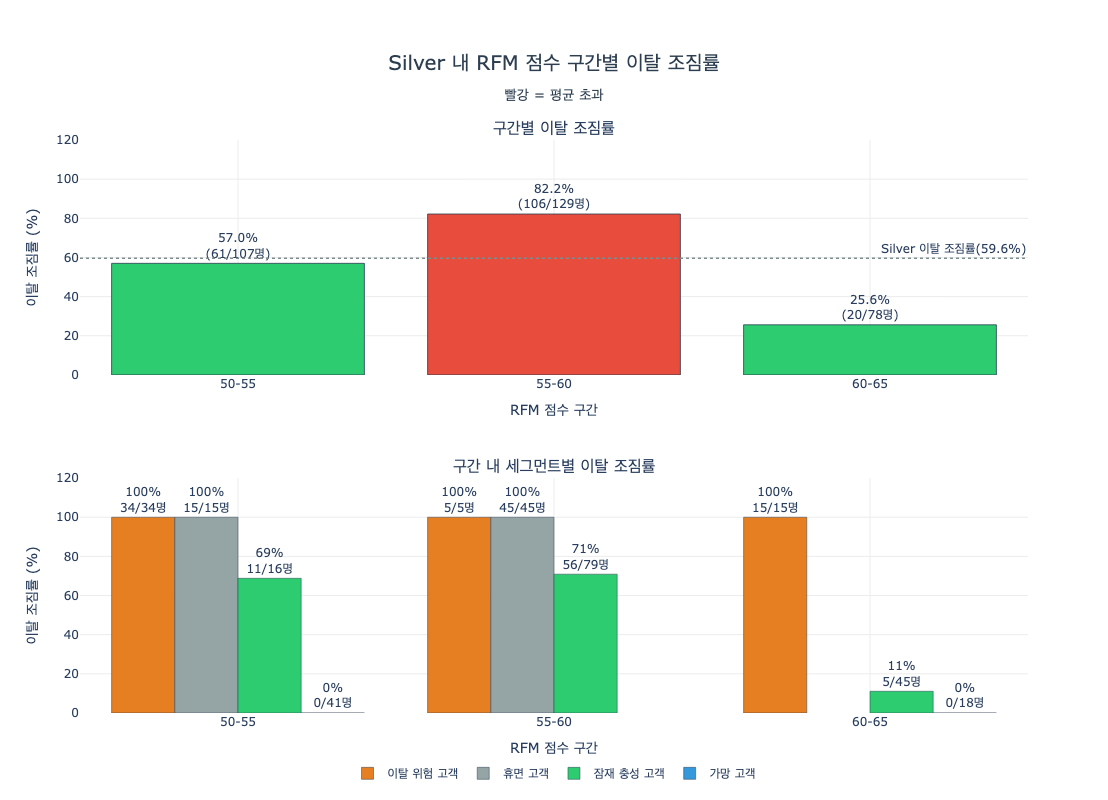

In [25]:
avg_rate = round(h41_data['이탈조짐'].mean() * 100, 1)
colors = ['#e74c3c' if r > avg_rate else '#2ecc71' for r in h41_bin['이탈조짐률']]

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['구간별 이탈 조짐률', '구간 내 세그먼트별 이탈 조짐률'],
    vertical_spacing=0.18
)

fig.add_trace(go.Bar(
    x=h41_bin['점수구간'].astype(str),
    y=h41_bin['이탈조짐률'],
    text=[
        f"{row['이탈조짐률']:.1f}%<br>({int(row['이탈조짐수'])}/{int(row['고객수'])}명)"
        for _, row in h41_bin.iterrows()
    ],
    textposition='outside',
    marker=dict(color=colors, line=dict(color='#2c3e50', width=0.8)),
    showlegend=False,
), row=1, col=1)

seg_order = ['이탈 위험 고객', '휴면 고객', '잠재 충성 고객', '가망 고객']
for seg in seg_order:
    sub = h41_seg[h41_seg['세그먼트'] == seg]
    if len(sub) == 0:
        continue
    fig.add_trace(go.Bar(
        x=sub['점수구간'].astype(str),
        y=sub['이탈조짐률'],
        name=seg,
        marker=dict(color=seg_color.get(seg, '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        text=[f"{v:.0f}%<br>{n}/{t}명" for v, n, t in zip(sub['이탈조짐률'], sub['이탈조짐수'], sub['고객수'])],
        textposition='outside',
    ), row=2, col=1)

fig.add_hline(
    y=avg_rate,
    line_dash='dot', line_color='#7f8c8d', line_width=1.5,
    annotation_text=f'Silver 이탈 조짐률({avg_rate}%)',
    annotation_position='top right',
    row=1, col=1
)

fig.update_layout(
    title=dict(
        text='Silver 내 RFM 점수 구간별 이탈 조짐률<br><sub>빨강 = 평균 초과</sub>',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    barmode='group',
    plot_bgcolor='white',
    margin=dict(t=140),
    height=800,
    legend=dict(orientation='h', yanchor='top', y=-0.08, xanchor='center', x=0.5)
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_xaxes(title_text='RFM 점수 구간', row=1, col=1)
fig.update_yaxes(title_text='이탈 조짐률 (%)', range=[0, 120], row=1, col=1)
fig.update_xaxes(title_text='RFM 점수 구간', row=2, col=1)
fig.update_yaxes(title_text='이탈 조짐률 (%)', range=[0, 120], row=2, col=1)
fig.show()

> 📌 **참고**: 구간별 이탈 조짐률(상단)의 50-55 구간은 61명이지만 세그먼트별 차트(하단)는 60명으로 1명 차이가 있다. 이는 분석에서 제외된 **놓치면 안될 고객(1명)** 이 50-55 구간에 포함되어 있기 때문이다.

> ### 📊 가설 3-1 검증 결과: 기각 (비선형 패턴 발견)
>
> | 점수 구간 | 고객수 | 이탈 조짐수 | 이탈 조짐률 | 주요 세그먼트 구성 |
> | :---: | :---: | :---: | :---: | :--- |
> | 50-55 | 107명 | 61명 | 57.0% | 가망(41명/0%) · 이탈위험(34명/100%) · 잠재충성(16명/68.8%) · 휴면(15명/100%) |
> | 55-60 | 129명 | 106명 | **82.2%** | 잠재충성(79명/70.9%) · 휴면(45명/100%) · 이탈위험(5명/100%) |
> | 60-65 | 78명 | 20명 | **25.6%** | 잠재충성(45명/11.1%) · 가망(18명/0%) · 이탈위험(15명/100%) |
>
> **💡 핵심 요약**
> RFM 점수가 낮을수록 이탈 조짐률이 높다는 단조 감소 가설과 달리, **중간 구간(55-60)이 최고치**를 기록하는 비선형 패턴이 나타났다. 이탈 조짐률을 결정하는 것은 점수 구간 자체가 아닌 **세그먼트 구성 차이**다.
>
> - 📉 **50-55 구간 (57.0%)**: 가망 고객(41명, R=5)이 구간의 38%를 차지하며 이탈 조짐률(0%)로 희석시킨다. 이탈위험·휴면(합산 49명, 모두 100%)이 나머지를 주도.
> - 📈 **55-60 구간 급등 (82.2%)**: 휴면(45명, 100%)과 잠재충성(79명, 70.9%)이 집중 — Recency가 경계값(90일)을 막 초과한 잠재충성이 이 구간을 채운다.
> - 📉 **60-65 구간 급락 (25.6%)**: 잠재충성 45명(R=4, 이탈조짐률 11.1%)이 구간의 58%를 차지하며 전체 비율을 낮춘다. 단, 이탈위험 15명(100%)은 여전히 존재한다.
>
> - 🔗 **가설 4와의 연결**: 이탈 위험 고객(Recency 중앙값 278일, `$3,328`)은 모든 구간에서 100% 이탈 조짐 — 고가치이면서 전 구간에 걸쳐 이탈의 핵심 원인이다.

---
## 가설 4 — Silver 이탈 세그먼트는 안정 세그먼트보다 1인당 구매금액이 낮다

> **가설 4**: Silver의 휴면·이탈 위험 고객은 잠재 충성·가망보다 Monetary가 낮은 저가치 이탈일 것이다.
>
> - 근거: Gold·Platinum에서는 이탈 조짐 고객이 역설적으로 고가치였음 — Silver는 등급 특성상 다를 수 있음
> - 역설 발견 시: Silver 이탈군도 고가치라면 재참여 ROI 재평가 필요
> - 검증: 세그먼트별 Monetary(1인당 총 구매금액) 중앙값·평균 비교

In [18]:
h4_data = pd.read_sql(
    """
    SELECT
        세그먼트,
        Monetary
    FROM rfm_result
    WHERE 등급 = 'Silver'
        AND 세그먼트 != '놓치면 안될 고객'
    """,
    engine
)
h4_data.head()

,세그먼트,Monetary
0,가망 고객,1339.57
1,휴면 고객,1369.94
2,잠재 충성 고객,2217.09
3,잠재 충성 고객,3182.75
4,잠재 충성 고객,1744.39


In [19]:
h4_agg = (
    h4_data.groupby('세그먼트')['Monetary']
    .agg(['mean', 'median'])
    .rename(columns={'mean': '평균', 'median': '중앙값'})
    .reset_index()
)
h4_agg['평균'] = h4_agg['평균'].round(0)
h4_agg['중앙값'] = h4_agg['중앙값'].round(0)
h4_agg = h4_agg.sort_values('중앙값', ascending=False)
h4_agg

,세그먼트,평균,중앙값
1,이탈 위험 고객,3256.0,3328.0
2,잠재 충성 고객,2577.0,2470.0
3,휴면 고객,2366.0,2428.0
0,가망 고객,1561.0,1340.0


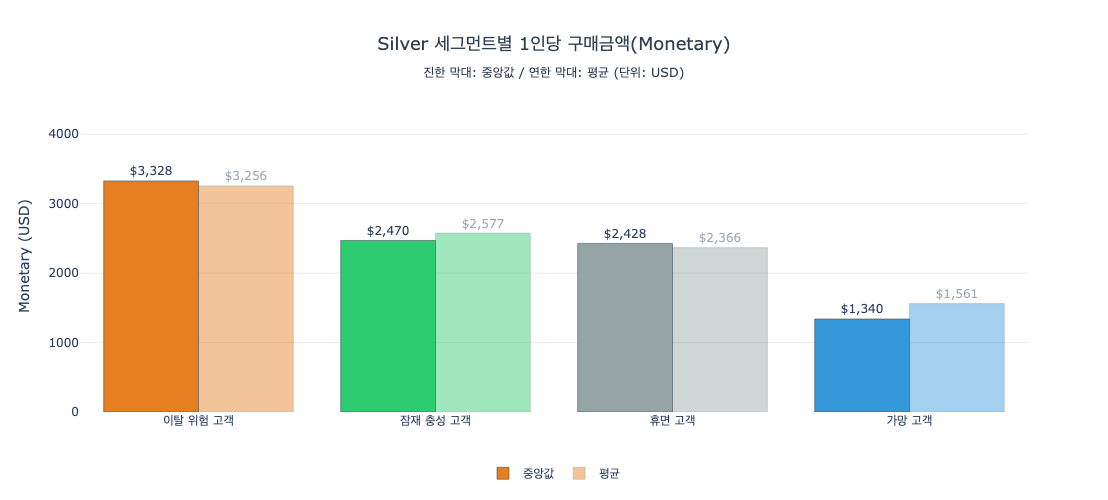

In [20]:
seg_colors = {
    '잠재 충성 고객': '#2ecc71',
    '가망 고객': '#3498db',
    '휴면 고객': '#95a5a6',
    '이탈 위험 고객': '#e67e22',
}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='중앙값',
    x=h4_agg['세그먼트'],
    y=h4_agg['중앙값'],
    marker=dict(
        color=[seg_colors.get(s, '#cccccc') for s in h4_agg['세그먼트']],
        line=dict(color='#2c3e50', width=0.5)
    ),
    text=[f"${v:,.0f}" for v in h4_agg['중앙값']],
    textposition='outside',
    textfont=dict(size=12),
))

fig.add_trace(go.Bar(
    name='평균',
    x=h4_agg['세그먼트'],
    y=h4_agg['평균'],
    marker=dict(
        color=[seg_colors.get(s, '#cccccc') for s in h4_agg['세그먼트']],
        line=dict(color='#2c3e50', width=0.5)
    ),
    opacity=0.45,
    text=[f"${v:,.0f}" for v in h4_agg['평균']],
    textposition='outside',
    textfont=dict(size=12),
))

fig.update_layout(
    title=dict(
        text='Silver 세그먼트별 1인당 구매금액(Monetary)<br><sub>진한 막대: 중앙값 / 연한 막대: 평균 (단위: USD)</sub>',
        x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')
    ),
    barmode='group',
    plot_bgcolor='white',
    yaxis=dict(
        title='Monetary (USD)',
        range=[0, max(h4_agg['평균'].max(), h4_agg['중앙값'].max()) * 1.35],
        gridcolor='#ececec'
    ),
    xaxis=dict(title=''),
    legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5),
    height=500,
)
fig.show()

> ### 📊 가설 4 검증 결과: 기각
>
> | 세그먼트 | Monetary 중앙값 | Monetary 평균 | 분포 특징 |
> |---------|:-----------:|:----------:|---------|
> | 이탈 위험 고객 | **`$3,328`** | `$3,256` | 평균≈중앙값 → 고르게 분포 |
> | 잠재 충성 고객 | `$2,470` | `$2,577` | 평균>중앙값 → 소수 고가치 고객 존재 |
> | 휴면 고객 | `$2,428` | `$2,366` | 평균≈중앙값 → 고르게 분포 |
> | 가망 고객 | `$1,340` | `$1,561` | 평균>중앙값 → 소수 고가치 고객 존재 |
>
> **💡 핵심 요약**
> - 이탈 위험(`$3,328`)이 잠재 충성(`$2,470`)보다 1인당 구매금액이 높다 — 이탈 세그먼트가 저가치라는 가설이 기각된다.
> - Gold·Platinum에서도 이탈 조짐 고객이 고가치였던 패턴이 Silver에서 반복된다.
> - **Recency 손실이 가치 손실이 아니다** — 이탈 위험은 구매력은 있으나 최근성만 낮아진 상태이므로 재참여 ROI가 높다.
> - 가망(`$1,340`)은 Silver 내 최저가치이나 R=5(최근성 최고) — 구매를 지속할 가능성이 가장 높은 군이다.
>
> > ✅ **액션 아이템**: 이탈 위험(54명, 중앙값 `$3,328`) → 개인화 재방문 쿠폰·이메일 재참여 캠페인 우선 집행

---
## 결론 및 핵심 인사이트

Silver는 전체 고객의 **21.4%(314명)**, 매출 **16.1%** 를 담당하는 성장 잠재층이다. 재방문율 57.0%는 Gold(74.1%) 대비 17%p 낮고, 이탈 조짐 고객(187명, 59.6%)이 Gold(53.5%)보다 많다.

---

### 발견 1 — 재방문율은 이분화가 아닌 세그먼트별 복합 구조로 결정된다 _(가설 1)_

이탈군인 휴면(56.7%)이 안정군인 가망(49.2%)보다 재방문율이 높아 단순 이분화 구조가 아니다. **Recency가 각 세그먼트를 가르는 결정적 변수**다.

- **Recency 비교**: 278.0일(이탈위험) · 194.0일(휴면) · 91.5일(잠재충성) · 20.0일(가망)
- **이탈 위험**: Recency 중앙값 278일로 Silver 내 최장 침묵 — Silver 전체 재방문율을 가장 강하게 끌어내린다
- **잠재 충성**: Recency 중앙값 91.5일로 이탈 조짐 경계(90일)에 위치 — 방치 시 이탈군으로 전환 위험

---

### 발견 2 — 이탈 시점은 세그먼트별로 달라 단일 캠페인으로 커버 불가 _(가설 2)_

Silver 고객 **59.6%(187명)** 이 이탈 조짐 상태로 Gold(53.5%)보다 높다 — 이탈은 예외가 아닌 구조적 특성이다. 연중 90일+ 공백 경험은 **73.0%(229명)** 이며, 공백 이후 복귀에 성공한 고객도 **42명(13.4%)** 존재한다.

- **이탈 후 복귀 (42명)**: 공백을 극복하고 현재 정상 방문 중인 잠재충성(27명)·가망(15명) — 재활성화 캠페인의 실증 레퍼런스
- **이탈 위험**: 1-4월 집중 (상반기 마지막 구매 후 이탈)
- **휴면**: 5-8월 집중 (여름 마지막 구매 후 장기 이탈)
- Gold의 여름 집중이 8월 최다(48명)로 부분 재현되나, 세그먼트별로 이탈 시점이 분산돼 **등급별·세그먼트별 맞춤 타이밍 전략**이 필요하다.

---

### 발견 3 — Gold 전환 경로와 이탈 조짐 구간은 세그먼트 구성에 좌우된다 _(가설 3·3-1)_

| 세그먼트 | Gold 갭 (중앙값) | R 중앙값 | F·M 중앙값 | 전환 경로 |
|---------|:-------------:|:------:|:--------:|---------|
| 잠재 충성 고객 | **5.0점** | 4.0 | F=3·M=3 | F·M 누적 |
| 휴면 고객 | 9.0점 | 2.0 | F=3·M=3 | Recency 회복 후 F·M 유지 |
| 가망 고객 | 12.9점 | 5.0 | F=2·M=2 | F·M 동시 누적 |
| 이탈 위험 고객 | 13.0점 | 1.0 | F=3·M=3 | 재참여 후 Recency 회복 |

**잠재 충성(5.0점)이 Silver 내 Gold 전환 최근접** — R=4로 최근성이 높고, F·M=3이 공통 기준선을 충족하며, 구매 1-2회 추가로 전환 진입이 가능하다. 이탈위험·가망(~13점)은 Gold 전환보다 Silver 등급 유지 자체가 우선 과제다.

RFM 점수 구간별 이탈 조짐률도 세그먼트 구성에 따라 비선형으로 움직인다.

- **점수 구간별 이탈 조짐률**: 50-55(57.0%) → 55-60(**82.2%**) → 60-65(25.6%) — U자형 비선형
- **55-60 구간 급등**: 잠재충성 79명(70.9%)이 이 구간에 집중 — Gold 전환 최근접 대상이 동시에 이탈 고위험 구간에 위치
- **60-65 구간 급락**: 잠재충성 45명(11.1%)이 구간 58%를 차지하며 비율을 낮춤

---

### 발견 4 — 이탈 세그먼트가 역설적으로 고가치다 _(가설 4)_

이탈 위험(`$3,328`)이 잠재 충성(`$2,470`)보다 1인당 구매금액이 높다. Gold·Platinum에서 반복된 패턴이다.

- **이탈 위험은 모든 RFM 구간에서 100% 이탈 조짐** — Recency만 낮아진 상태이므로 재참여 ROI가 가장 높다
- **가망(`$1,340`)은 Silver 내 최저가치이나 R=5** — 구매를 지속할 가능성이 가장 높은 군
- **Recency 손실이 가치 손실이 아니다** — 이탈 세그먼트를 단순 저가치로 분류하면 고ROI 재참여 기회를 놓친다

---

> 📌 **Silver 등급 핵심 전략**
>
> 1. **Gold 전환 집중 타깃**: 잠재 충성(140명, 갭 5.0점) → F·M 부스터 캠페인 (구매 빈도·금액 1-2회 증가)
> 2. **고위험 이탈 방어**: 이탈 위험(54명, `$3,328`) → 재참여 캠페인 선행 (마지막 구매 후 60-90일 시점 접촉)
> 3. **세그먼트별 타이밍 분리**: 이탈위험(1-4월) vs 휴면(5-8월) — 재활성화 캠페인 시기 분리
> 4. **잠재 충성 이탈 방어**: Recency 중앙값 91.5일로 이탈 조짐 경계 — 등급 유지 혜택 리마인더로 선제 대응

> ✅ **세그먼트별 액션 아이템**
>
> **🌱 잠재 충성 고객 (140명, Gold 갭 5.0점)**
> - Gold 전환 최근접 — "Gold까지 X번 더 구매" 진행률 알림 + F·M 부스터 쿠폰
> - Recency 중앙값 91.5일: 이탈 조짐 경계선 — 방치 시 55-60 구간(이탈 조짐률 82%)으로 전락 위험
>
> **⚡ 이탈 위험 고객 (54명, `$3,328`)**
> - 고가치 이탈층 — Recency 회복 시 Gold 갭(13.0점) 단축 가능
> - 마지막 구매 후 60-90일 시점 개인화 재방문 쿠폰 선행 집행
>
> **💤 휴면 고객 (60명)**
> - 5-8월 이탈 집중 — 여름 시즌 직전(4-5월) 재활성화 캠페인 타이밍
> - F·M=3으로 구매력 있음 — 복귀 가능성 확인 후 단계별 접근
>
> **🔍 가망 고객 (59명)**
> - R=5(최근성 최고)이나 F·M=2로 Silver 내 최저가치 — 등급 유지 관점의 육성 캠페인
> - 이탈 조짐률 0% — 비교적 안정적이나 구매 빈도 증대 필요

> 🧪 **A/B 테스트 제안**
>
> - **실험 단위**: 고객 단위 랜덤 할당
> - **표본 한계**: Silver 314명 — 세그먼트당 59-140명으로 소규모, 3-6개월 누적 후 판단 권장
>
> **잠재 충성 고객 — Gold 전환 알림 효과 (140명)**
> - 가설: "Gold까지 X번 더 구매" 진행률 알림이 일반 재방문 유도보다 Gold 전환율이 높을 것이다
> - A그룹: 일반 재방문 유도 쿠폰 / B그룹: Gold 전환 진행률 알림 + 소액 인센티브
> - **주요 지표**: 발송 후 90일 내 Gold 전환율 / **보조 지표**: 재방문율, AOV
>
> **이탈 위험 고객 — 재참여 타이밍 (54명)**
> - 가설: 마지막 구매 후 60-90일 시점 선제 접촉이 120일 이후보다 재방문율이 높을 것이다
> - A그룹: 120일+ 경과 후 접촉 / B그룹: 60-90일 시점 선제 메시지
> - **주요 지표**: 발송 후 30일 내 재방문율 / **보조 지표**: AOV, Recency 단축 일수